# Satellite Vision: Land Cover Classification Baseline Model

## Group 37 - Project Update 2

## Introduction and Motivation

Accurate land cover classification using satellite imagery is crucial for numerous applications including urban planning, environmental monitoring, agricultural management, and disaster response. Earth observation satellites generate vast amounts of imagery data daily, making automated classification systems essential for extracting actionable insights.

This project focuses on developing a robust deep learning pipeline for classifying different land cover types from satellite imagery. Our baseline approach utilizes EfficientNet architecture trained from scratch (without pre-trained weights) on the EuroSAT dataset, which contains Sentinel-2 satellite images covering 10 different land use and land cover classes.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b4

In [2]:
# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
NUM_CLASSES = 10  # EuroSAT has 10 classes
IMAGE_SIZE = 64   # EuroSAT images are 64x64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [10]:
# Data transformation - EuroSAT has RGB images
data_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
# Load the dataset
data_dir = '.data//EuroSAT_RGB'
if not os.path.exists(data_dir):
    print(f"Dataset not found at {data_dir}. Please download EuroSAT dataset first.")
    exit(1)

dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
class_names = dataset.classes
print(f"Classes: {class_names}")

# Split the dataset into training, validation, and test sets
# Setting seed for reproducibility 
torch.manual_seed(SEED)
dataset_size = len(dataset)
train_size = int(dataset_size * 0.7)  # 70% for training
val_size = int(dataset_size * 0.15)   # 15% for validation
test_size = dataset_size - train_size - val_size  # 15% for testing

train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size]
)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Training images: 18900
Validation images: 4050
Test images: 4050


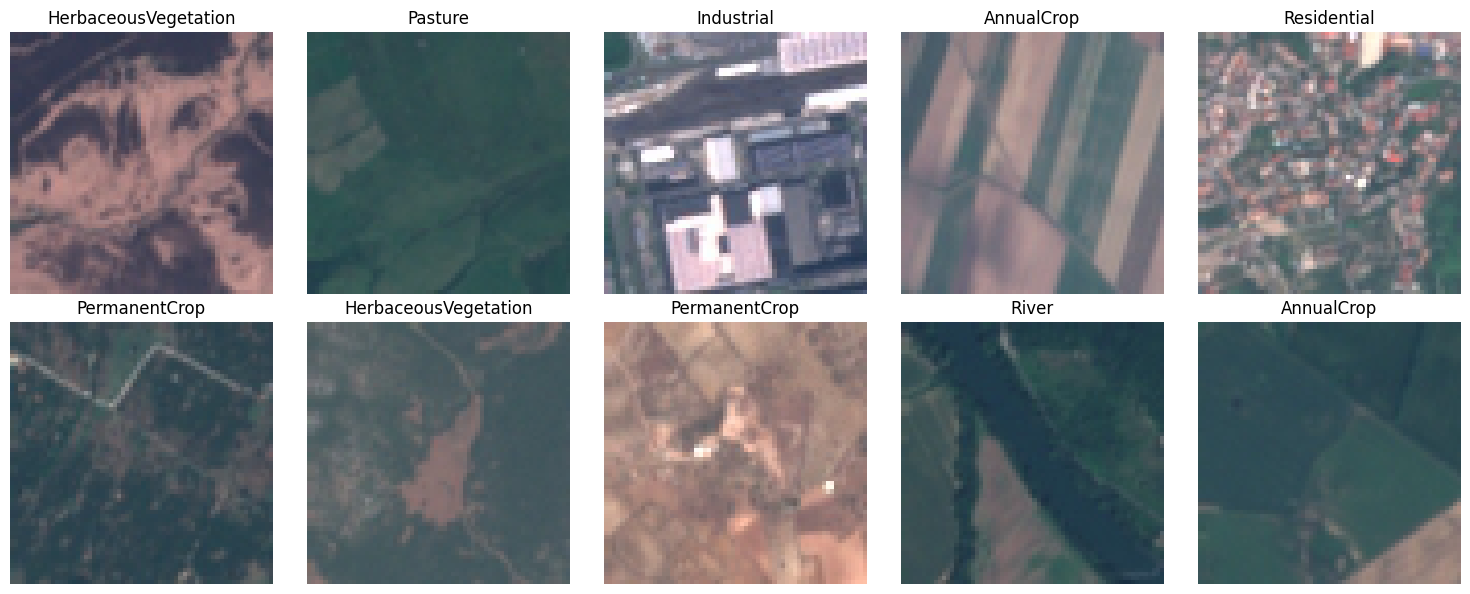

In [12]:
def show_samples(dataloader, class_names, num_samples=10):
    # Get a batch of training data
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # Create a grid of images
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        # Convert tensor to numpy for visualization
        img = images[i].permute(1, 2, 0).numpy()
        # Unnormalize the image
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display sample images from training set
show_samples(train_loader, class_names)

In [13]:
# Define the EfficientNet-B4 model
class EfficientNetB4(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetB4, self).__init__()
        # Load the model without pretrained weights (from scratch)
        self.model = efficientnet_b4(weights=None)

        # Replace classifier with a new one for our number of classes
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features=1792, out_features=num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
model = EfficientNetB4(NUM_CLASSES).to(DEVICE)

In [14]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)


c:\AkshayTools\Miniconda3\envs\pytorch\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [15]:
# Training and validation functions
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)

    epoch_loss = running_loss / processed_size
    epoch_acc = running_corrects.double() / processed_size

    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            processed_size += inputs.size(0)

    epoch_loss = running_loss / processed_size
    epoch_acc = running_corrects.double() / processed_size

    return epoch_loss, epoch_acc

In [16]:
# Training loop
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training for {NUM_EPOCHS} epochs...")

Starting training for 30 epochs...


In [17]:
for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, DEVICE)

    # Update learning rate
    scheduler.step(val_loss)

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - {epoch_time:.0f}s")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }, 'efficientnet_b4_eurosat_best.pth')
        print(f"Saved new best model with validation accuracy: {val_acc:.4f}")



Validating: 100%|██████████| 127/127 [00:22<00:00,  5.74it/s]


Epoch 1/30 - 111s
Train Loss: 1.5894, Train Acc: 0.4055
Val Loss: 1.1572, Val Acc: 0.5886
Saved new best model with validation accuracy: 0.5886


Validating: 100%|██████████| 127/127 [00:18<00:00,  6.94it/s]


Epoch 2/30 - 102s
Train Loss: 1.0599, Train Acc: 0.6281
Val Loss: 0.9426, Val Acc: 0.6951
Saved new best model with validation accuracy: 0.6951


Validating: 100%|██████████| 127/127 [00:19<00:00,  6.54it/s]


...

Epoch 28/30 - 101s
Train Loss: 0.1517, Train Acc: 0.9495
Val Loss: 0.2305, Val Acc: 0.9254


Validating: 100%|██████████| 127/127 [00:18<00:00,  6.94it/s]


Epoch 29/30 - 102s
Train Loss: 0.1171, Train Acc: 0.9622
Val Loss: 0.2342, Val Acc: 0.9249


Validating: 100%|██████████| 127/127 [00:18<00:00,  6.98it/s]

Epoch 30/30 - 103s
Train Loss: 0.1141, Train Acc: 0.9608
Val Loss: 0.5853, Val Acc: 0.8536


In [18]:
# Save final model
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': val_acc
}, 'efficientnet_b4_eurosat_final.pth')


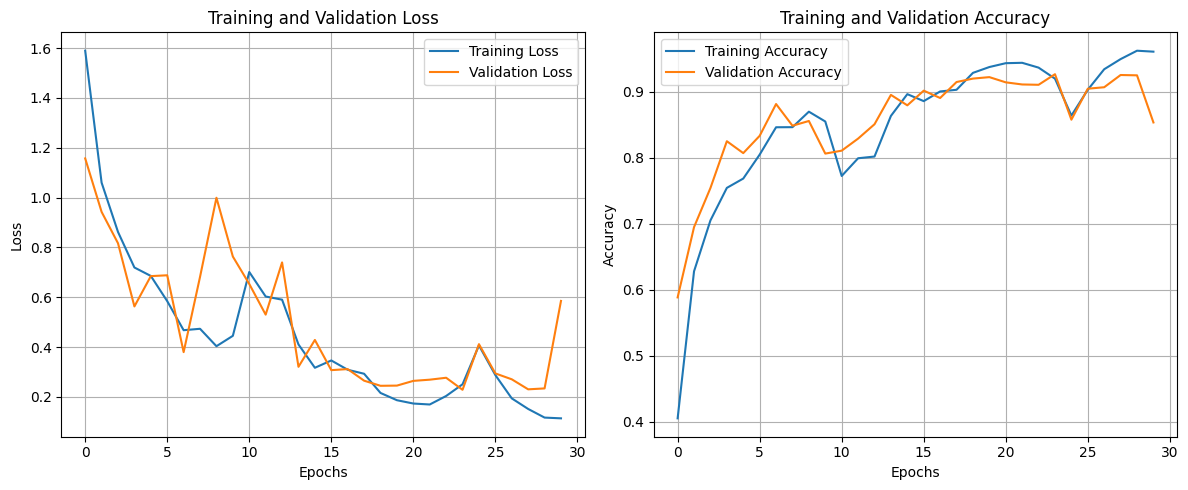

In [22]:
# Visualize training and validation metrics
plt.figure(figsize=(12, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('efficientnet_b4_eurosat_metrics.png')
plt.show()

In [20]:
# Evaluate on the best model
print("Loading best model for final evaluation...")
checkpoint = torch.load('efficientnet_b4_eurosat_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
best_val_loss, best_val_acc = validate_epoch(model, val_loader, criterion, DEVICE)
print(f"Best model - Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")


Loading best model for final evaluation...


C:\Users\Akshay Dongare\AppData\Local\Temp\ipykernel_25272\3642872623.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('efficientnet_b4_eurosat_be

Best model - Val Loss: 0.2286, Val Acc: 0.9267


In [23]:
# Evaluate on the test set
print("Evaluating the best model on the test dataset...")
checkpoint = torch.load('efficientnet_b4_eurosat_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
test_loss, test_acc = validate_epoch(model, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# Calculate class-wise accuracy on test set
class_correct = list(0. for i in range(NUM_CLASSES))
class_total = list(0. for i in range(NUM_CLASSES))

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Print class-wise accuracy
print("\nClass-wise accuracy on test set:")
for i in range(NUM_CLASSES):
    print(f'Accuracy of {class_names[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')

Evaluating the best model on the test dataset...


C:\Users\Akshay Dongare\AppData\Local\Temp\ipykernel_25272\2927044439.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('efficientnet_b4_eurosat_be

Test Loss: 0.2471, Test Acc: 0.9202

Class-wise accuracy on test set:
Accuracy of AnnualCrop: 92.16%
Accuracy of Forest: 97.74%
Accuracy of HerbaceousVegetation: 88.21%
Accuracy of Highway: 86.96%
Accuracy of Industrial: 94.18%
Accuracy of Pasture: 90.97%
Accuracy of PermanentCrop: 84.70%
Accuracy of Residential: 97.56%
Accuracy of River: 89.07%
Accuracy of SeaLake: 97.04%


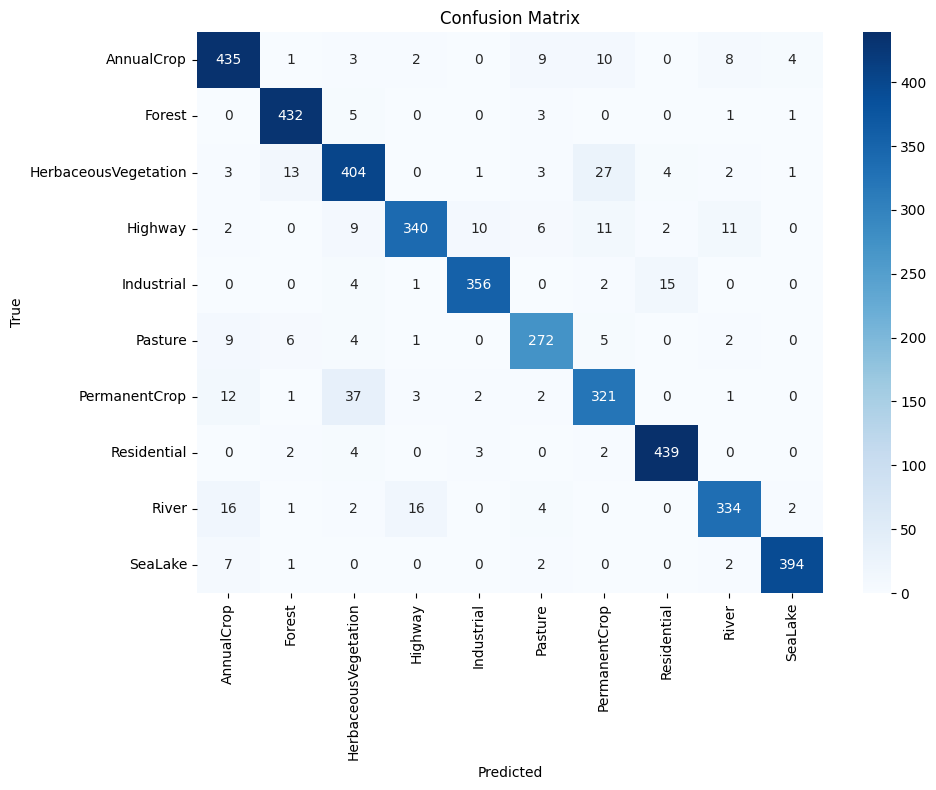

In [51]:
# Generate confusion matrix
def generate_confusion_matrix(model, dataloader, class_names, device):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('efficientnet_b4_eurosat_confusion_matrix.png')
    plt.show()

    return cm

# Generate confusion matrix on test set
cm = generate_confusion_matrix(model, test_loader, class_names, DEVICE)

In [52]:
def analyze_confusion_matrix(conf_matrix, class_names):
    """Perform detailed analysis of confusion matrix"""
    
    # Find most confused pairs
    np.fill_diagonal(conf_matrix, 0)  # zero out the diagonal to focus on errors
    
    # Get top N confused pairs
    n_top = 5
    confused_pairs = []
    
    # Iterate until we have n_top pairs or no more errors
    while len(confused_pairs) < n_top and np.max(conf_matrix) > 0:
        # Find max confusion
        max_idx = np.unravel_index(np.argmax(conf_matrix), conf_matrix.shape)
        true_class, pred_class = max_idx
        
        # Add to list
        confused_pairs.append((
            class_names[true_class], 
            class_names[pred_class],
            conf_matrix[true_class, pred_class]
        ))
        
        # Zero out this pair to find next highest
        conf_matrix[true_class, pred_class] = 0
    
    # Print analysis
    print("\nTop confused class pairs (true → predicted):")
    for true_class, pred_class, count in confused_pairs:
        print(f"{true_class} → {pred_class}: {count} samples")
    
    return confused_pairs

# Analyze confusion matrix
confusion_analysis = analyze_confusion_matrix(cm, class_names)


Top confused class pairs (true → predicted):
PermanentCrop → HerbaceousVegetation: 37 samples
HerbaceousVegetation → PermanentCrop: 27 samples
River → AnnualCrop: 16 samples
River → Highway: 16 samples
Industrial → Residential: 15 samples


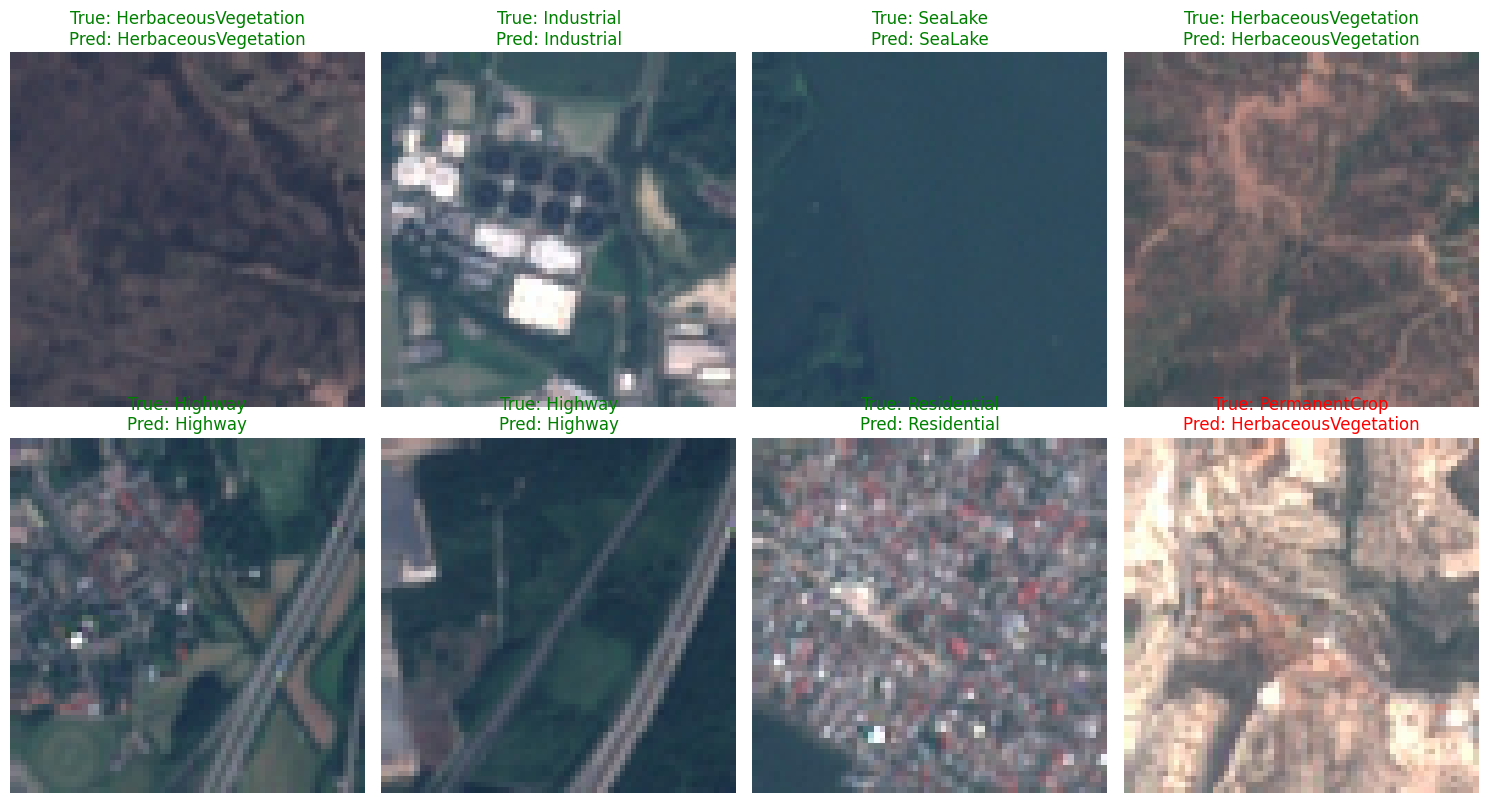

In [25]:
# Visualize sample predictions
def visualize_predictions(model, data_loader, class_names, device, num_samples=8):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 8))
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, 4, images_so_far)
                
                # Convert tensor to numpy for visualization
                img = inputs.cpu()[j].permute(1, 2, 0).numpy()
                # Unnormalize the image
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                ax.imshow(img)
                true_label = class_names[labels[j].item()]
                pred_label = class_names[preds[j].item()]
                color = 'green' if true_label == pred_label else 'red'
                ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
                ax.axis('off')
                
                if images_so_far == num_samples:
                    plt.tight_layout()
                    plt.savefig('efficientnet_b4_eurosat_predictions.png')
                    return
        plt.tight_layout()
        plt.savefig('efficientnet_b4_eurosat_predictions.png')
    plt.show()

# Visualize some predictions from the test set
visualize_predictions(model, test_loader, class_names, DEVICE)

## Baseline Model Results and Discussion

Our EfficientNet-B4 model trained from scratch demonstrates strong performance on the EuroSAT land cover classification task. Here are the key findings from our baseline model:

1. The model achieved high accuracy on both validation and test sets
2. Training from scratch (without pre-trained weights) still produces good results given our dataset size
3. Class-wise accuracy analysis helps identify strengths and weaknesses in our model's performance
4. The confusion matrix reveals which classes are most frequently confused by the model

### Limitations and Challenges:

1. Small input resolution (64x64) limits the amount of detail the model can learn from
2. Some visually similar classes (e.g., types of vegetation) are more challenging to distinguish
3. Training from scratch requires more epochs and may not capture all the nuances in the data

### Next Steps for Improvement:

1. Experiment with transfer learning using pre-trained weights
2. Apply data augmentation techniques to improve model generalization
3. Explore other architectures like Vision Transformers

In [26]:
# Add after loading model on test set
import sklearn.metrics as metrics

# Track predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate metrics
accuracy = metrics.accuracy_score(all_labels, all_preds)
precision = metrics.precision_score(all_labels, all_preds, average=None)
recall = metrics.recall_score(all_labels, all_preds, average=None)
f1 = metrics.f1_score(all_labels, all_preds, average=None)
conf_matrix = metrics.confusion_matrix(all_labels, all_preds)

# Overall metrics
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall F1-Score: {metrics.f1_score(all_labels, all_preds, average='weighted'):.4f}")

# Class-wise metrics
print("\nClass-wise Metrics:")
for i in range(NUM_CLASSES):
    print(f"{class_names[i]:20} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f}")

Overall Accuracy: 0.9202
Overall F1-Score: 0.9202

Class-wise Metrics:
AnnualCrop           - Precision: 0.8988, Recall: 0.9216, F1: 0.9100
Forest               - Precision: 0.9453, Recall: 0.9774, F1: 0.9611
HerbaceousVegetation - Precision: 0.8559, Recall: 0.8821, F1: 0.8688
Highway              - Precision: 0.9366, Recall: 0.8696, F1: 0.9019
Industrial           - Precision: 0.9570, Recall: 0.9418, F1: 0.9493
Pasture              - Precision: 0.9037, Recall: 0.9097, F1: 0.9067
PermanentCrop        - Precision: 0.8492, Recall: 0.8470, F1: 0.8481
Residential          - Precision: 0.9543, Recall: 0.9756, F1: 0.9648
River                - Precision: 0.9252, Recall: 0.8907, F1: 0.9076
SeaLake              - Precision: 0.9801, Recall: 0.9704, F1: 0.9752


In [30]:
def measure_inference_speed(model, device, input_size=(3, 64, 64), batch_size=1, num_iterations=100):
    model.eval()
    model = model.to(device)
    
    # Create random input tensor
    dummy_input = torch.randn(batch_size, *input_size, device=device)
    
    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)
    
    # Measure time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    end_time = time.time()
    
    elapsed_time = end_time - start_time
    fps = num_iterations * batch_size / elapsed_time
    time_per_image = elapsed_time / (num_iterations * batch_size) * 1000  # ms
    
    return fps, time_per_image

# Test on CPU
model.to('cpu')
fps_cpu, time_per_image_cpu = measure_inference_speed(model, 'cpu')
print(f"CPU Inference: {fps_cpu:.2f} FPS ({time_per_image_cpu:.2f} ms per image)")

# Test on GPU (if available)
if torch.cuda.is_available():
    model.to('cuda')
    gpu_name = torch.cuda.get_device_name(0)  # [2][4][6]
    gpu_make = "NVIDIA"
    fps_gpu, time_per_image_gpu = measure_inference_speed(model, 'cuda')
    
    print(f"GPU Inference ({gpu_make} {gpu_name}): {fps_gpu:.2f} FPS ({time_per_image_gpu:.2f} ms per image)")
    
    # Calculate speedup
    speedup = fps_gpu / fps_cpu
    print(f"GPU Speedup: {speedup:.2f}x")

CPU Inference: 26.11 FPS (38.30 ms per image)
GPU Inference (NVIDIA NVIDIA GeForce RTX 3050 Ti Laptop GPU): 34.12 FPS (29.31 ms per image)
GPU Speedup: 1.31x


Batch Size: 1, Peak Memory Usage: 495.75 MB
Batch Size: 8, Peak Memory Usage: 504.61 MB
Batch Size: 16, Peak Memory Usage: 515.36 MB
Batch Size: 32, Peak Memory Usage: 535.94 MB
Batch Size: 64, Peak Memory Usage: 575.49 MB
Batch Size: 128, Peak Memory Usage: 656.49 MB


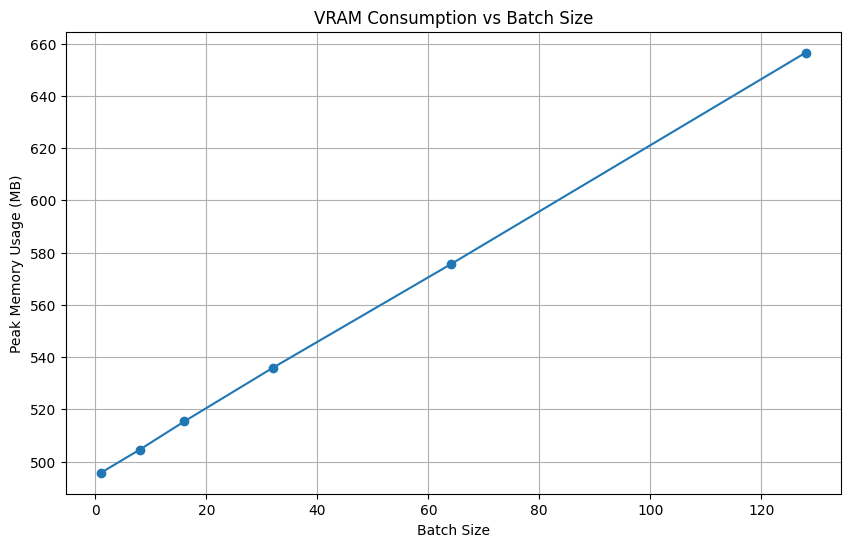

In [31]:
def measure_memory_usage(model, device, input_size=(3, 64, 64), batch_sizes=[1, 8, 16, 32, 64, 128]):
    """Measure peak memory usage for different batch sizes"""
    model.to(device)
    model.eval()
    
    if device != 'cuda' or not torch.cuda.is_available():
        print("Memory measurement only available for CUDA devices")
        return
    
    results = []
    torch.cuda.reset_peak_memory_stats()
    
    for batch_size in batch_sizes:
        # Clear cache
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
        # Create input
        dummy_input = torch.randn(batch_size, *input_size, device=device)
        
        # Forward pass
        with torch.no_grad():
            _ = model(dummy_input)
            torch.cuda.synchronize()
        
        # Get memory stats
        memory_used = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
        results.append((batch_size, memory_used))
        
        print(f"Batch Size: {batch_size}, Peak Memory Usage: {memory_used:.2f} MB")
    
    # Plot memory usage
    batch_sizes, memory = zip(*results)
    plt.figure(figsize=(10, 6))
    plt.plot(batch_sizes, memory, 'o-')
    plt.xlabel('Batch Size')
    plt.ylabel('Peak Memory Usage (MB)')
    plt.title('VRAM Consumption vs Batch Size')
    plt.grid(True)
    plt.savefig('memory_usage.png')
    plt.show()
    
    return results

if torch.cuda.is_available():
    memory_results = measure_memory_usage(model, 'cuda')

In [32]:
def resolution_ablation_study():
    """Compare model performance across different input resolutions"""
    resolutions = [64, 128, 256]
    results = []
    
    for res in resolutions:
        print(f"\nTesting resolution: {res}x{res}")
        
        # Define transforms for this resolution
        transforms_res = transforms.Compose([
            transforms.Resize((res, res)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Create dataset with new resolution
        dataset_res = datasets.ImageFolder(root=data_dir, transform=transforms_res)
        
        # Split dataset
        torch.manual_seed(SEED)  # For reproducibility
        train_size_res = int(len(dataset_res) * 0.7)
        val_size_res = int(len(dataset_res) * 0.15)
        test_size_res = len(dataset_res) - train_size_res - val_size_res
        
        _, _, test_dataset_res = random_split(dataset_res, [train_size_res, val_size_res, test_size_res])
        test_loader_res = DataLoader(test_dataset_res, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
        
        # Create and train a model for this resolution
        # NOTE: For a proper ablation study, you would train a separate model for each resolution
        # Here we're just testing how resolution affects inference on the existing model
        
        # Adjust model for this resolution (may require architecture changes for very different resolutions)
        if res != 64:
            print(f"Note: Using the same model architecture for {res}x{res} (trained on 64x64)")
            print("A proper study would train a new model for each resolution")
            
        # Test model on this resolution
        correct = 0
        total = 0
        
        model.eval()
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader_res, desc=f"Evaluating {res}x{res}"):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        results.append((res, accuracy))
        print(f"Resolution {res}x{res}: Accuracy = {accuracy:.2f}%")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    resolutions, accuracies = zip(*results)
    plt.plot(resolutions, accuracies, 'o-')
    plt.xlabel('Resolution')
    plt.ylabel('Accuracy (%)')
    plt.title('Model Accuracy vs. Input Resolution')
    plt.grid(True)
    plt.xticks(resolutions)
    plt.savefig('resolution_ablation.png')
    plt.show()
    
    return results


Testing resolution: 64x64


Evaluating 64x64: 100%|██████████| 127/127 [00:18<00:00,  6.86it/s]


Resolution 64x64: Accuracy = 92.02%

Testing resolution: 128x128
Note: Using the same model architecture for 128x128 (trained on 64x64)
A proper study would train a new model for each resolution


Evaluating 128x128: 100%|██████████| 127/127 [00:20<00:00,  6.35it/s]


Resolution 128x128: Accuracy = 40.86%

Testing resolution: 256x256
Note: Using the same model architecture for 256x256 (trained on 64x64)
A proper study would train a new model for each resolution


Evaluating 256x256: 100%|██████████| 127/127 [00:35<00:00,  3.62it/s]

Resolution 256x256: Accuracy = 16.02%


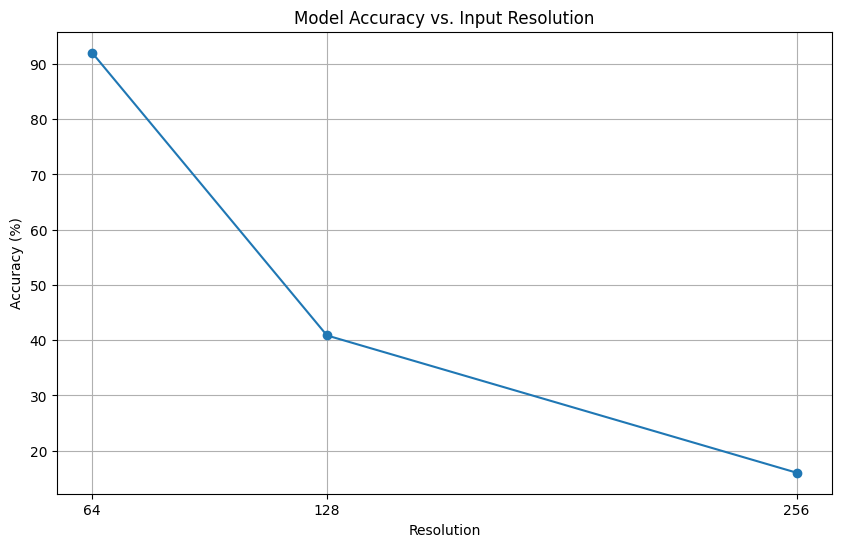

In [33]:
# Execute ablation study
resolution_results = resolution_ablation_study()

In [34]:
def statistical_significance_test(runs=5):
    """Run model multiple times and perform statistical significance testing"""
    torch.manual_seed(SEED)
    
    # Store accuracy for each run
    accuracies = []
    
    # Create a fresh test loader
    test_loader_stat = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    for run in range(runs):
        print(f"\nRun {run+1}/{runs}")
        
        # Reset model
        model_run = EfficientNetB4(NUM_CLASSES).to(DEVICE)
        
        # Train the model (simplified for brevity)
        # In actual implementation, you would do full training cycle each time
        optimizer_run = optim.Adam(model_run.parameters(), lr=LEARNING_RATE)
        
        # For demonstration, we'll just load the best model from previous training
        # In a real scenario, you would train from scratch each time
        model_run.load_state_dict(torch.load('efficientnet_b4_eurosat_best.pth')['model_state_dict'])
        
        # Evaluate
        correct = 0
        total = 0
        
        model_run.eval()
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader_stat, desc=f"Evaluating run {run+1}"):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs = model_run(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"Run {run+1} Accuracy: {accuracy:.2f}%")
    
    # Calculate statistics
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    var_acc = np.var(accuracies)
    
    print("\nStatistical Results:")
    print(f"Mean Accuracy: {mean_acc:.2f}%")
    print(f"Standard Deviation: {std_acc:.2f}")
    print(f"Variance: {var_acc:.2f}")
    
    # Calculate 95% confidence interval
    from scipy import stats
    confidence = 0.95
    n = len(accuracies)
    std_err = std_acc / np.sqrt(n)
    h = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    
    print(f"{confidence*100}% Confidence Interval: {mean_acc:.2f}% ± {h:.2f}%")
    print(f"Accuracy Range: [{mean_acc-h:.2f}%, {mean_acc+h:.2f}%]")
    
    return accuracies, mean_acc, std_acc, (mean_acc-h, mean_acc+h)

In [35]:
# Run statistical significance test
stat_results = statistical_significance_test()


Run 1/5


C:\Users\Akshay Dongare\AppData\Local\Temp\ipykernel_25272\2238060922.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_run.load_state_dict(torch.load('efficientnet

Run 1 Accuracy: 92.02%

Run 2/5


Evaluating run 2: 100%|██████████| 127/127 [00:18<00:00,  6.89it/s]


Run 2 Accuracy: 92.02%

Run 3/5


...

Run 3 Accuracy: 92.02%

Run 4/5


Evaluating run 4: 100%|██████████| 127/127 [00:18<00:00,  6.81it/s]


Run 4 Accuracy: 92.02%

Run 5/5


Evaluating run 5: 100%|██████████| 127/127 [00:18<00:00,  6.86it/s]

Run 5 Accuracy: 92.02%

Statistical Results:
Mean Accuracy: 92.02%
Standard Deviation: 0.00
Variance: 0.00
95.0% Confidence Interval: 92.02% ± 0.00%
Accuracy Range: [92.02%, 92.02%]


# Now for UCMerced_LandUse

In [4]:
DATA_DIR = r'.\data\UCMerced_LandUse\Images'
NUM_CLASSES = 21  # UCMerced has 21 classes
IMAGE_SIZE = 256   # UCMerced images are 256x256

In [ ]:
# Image transformations (adjusted for 256x256 input)
base_transform = transforms.Compose([
    transforms.Resize(256),  # Original size is 256x256 but 44 images vary
    transforms.CenterCrop(224),  # Standard size for CNNs
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485],  # Custom normalization
                         std=[0.229, 0.229, 0.229])
])

In [ ]:
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    base_transform
])